In [ ]:
# 1 - Imports + Load Original DF
import os, random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

2025-12-13 01:29:35.616281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-13 01:29:35.636392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765589375.663488    1789 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765589375.672406    1789 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765589375.695696    1789 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

   actor gender  emotion emotion_lb  \
0      1   male        1    neutral   
1      1   male        1    neutral   
2      1   male        1    neutral   
3      1   male        1    neutral   
4      1   male        2       calm   

                                                path  dataset  length_sec  \
0  Data/Processed_Audio/Actor_01/03-01-01-01-01-0...  RAVDESS       1.344   
1  Data/Processed_Audio/Actor_01/03-01-01-01-01-0...  RAVDESS       1.312   
2  Data/Processed_Audio/Actor_01/03-01-01-01-02-0...  RAVDESS       1.280   
3  Data/Processed_Audio/Actor_01/03-01-01-01-02-0...  RAVDESS       1.280   
4  Data/Processed_Audio/Actor_01/03-01-02-01-01-0...  RAVDESS       1.568   

   sentiment sentiment_name  
0          1       Moderate  
1          1       Moderate  
2          1       Moderate  
3          1       Moderate  
4          1       Moderate  
sentiment
0    8244
2    2759
1    2171
Name: count, dtype: int64


/tmp/ipykernel_1789/1983152500.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_name", palette=["green", "gray", "red"])


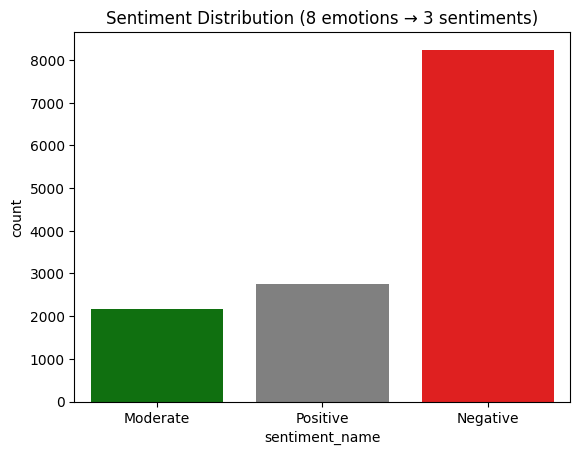

In [ ]:
# 2- Sentiment Distribution
df = pd.read_csv("DataFrame/processed_df.csv")

# Map emotion labels to sentiment groups
emotion_to_sentiment = {
    "angry": -1,
    "fearful": -1,
    "disgust": -1,
    "sad": -1,
    "neutral": 0,
    "calm": 0,
    "happy": 1,
    "surprised": 1
}

# Derive sentiment, clean, remap to [0,1,2]
df["sentiment"] = df["emotion_lb"].map(emotion_to_sentiment)
df = df.dropna(subset=["sentiment"])
df["sentiment"] = df["sentiment"].astype(int)
df["sentiment"] = df["sentiment"].map({-1: 0, 0: 1, 1: 2}).astype(int)

# Normalize paths for Linux/Windows
df["path"] = df["path"].str.replace("\\", "/", regex=False)

sentiment_label_map = {0: "Negative", 1: "Moderate", 2: "Positive"}
df["sentiment_name"] = df["sentiment"].map(sentiment_label_map)

df.to_csv("DataFrame/processed_sentiment_df.csv", index=False)

print(df.head())
print(df["sentiment"].value_counts())

sns.countplot(data=df, x="sentiment_name", palette=["green", "gray", "red"])
plt.title("Sentiment Distribution (8 emotions → 3 sentiments)")
plt.show()


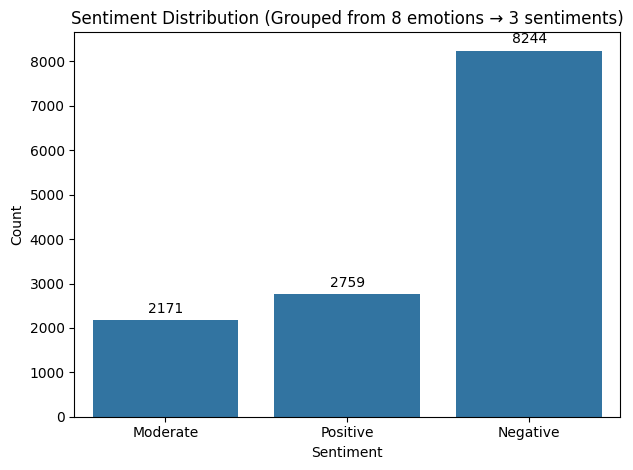

In [ ]:
ax = sns.countplot(data=df, x="sentiment_name")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", padding=3)

plt.title("Sentiment Distribution (Grouped from 8 emotions → 3 sentiments)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 3 - Data Augmentation Functions
def pitch_shift(y, sr=16000):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=random.choice([-2, -1, 1, 2]))

def time_stretch(y):
    rate = random.choice([0.8, 0.9, 1.1, 1.2])
    return librosa.effects.time_stretch(y=y, rate=rate)

def add_noise(y):
    noise = np.random.normal(0, 0.01, y.shape)
    return y + noise

AUG_FUNCS = [pitch_shift, time_stretch, add_noise]

def augment_audio(y, sr=16000):
    func = random.choice(AUG_FUNCS)
    return func(y)

In [ ]:
# 4 - Create Balanced Sentiment Dataset
from tqdm import tqdm
import random
def create_balanced_sentiment(df):
    # Fix Windows → Linux paths
    df["path"] = df["path"].str.replace("\\", "/", regex=False)

    groups = df.groupby("sentiment")
    max_size = groups.size().max()

    augmented_rows = []

    print("Balancing sentiment groups...\n")

    for s, group in groups:
        count = len(group)
        need = max_size - count

        print(f"\n Sentiment: {s}")
        print(f"   Current samples: {count}")
        print(f"   Need to generate: {need}")

        if need <= 0:
            augmented_rows.append(group)
            continue

        # Choose rows that will be augmented
        sample = group.sample(need, replace=True)

        # Progress bar for augmentation
        for _, row in tqdm(sample.iterrows(), 
                           total=len(sample),
                           desc=f"Augmenting {s}", 
                           leave=True):

            if not os.path.exists(row["path"]):
                print(f"⚠ Missing file: {row['path']}")
                continue

            # Load audio
            y, sr = librosa.load(row["path"], sr=16000)

            # Apply augmentation
            y_aug = augment_audio(y)

            # Save augmented file
            new_path = row["path"].replace(".wav", f"_aug_{random.randint(1,99999)}.wav")
            sf.write(new_path, y_aug, sr)

            # Add row to dataset
            new_row = row.copy()
            new_row["path"] = new_path
            augmented_rows.append(pd.DataFrame([new_row]))

        augmented_rows.append(group)

    df_final = pd.concat(augmented_rows, ignore_index=True)
    df_final.to_csv("DataFrame/processed_sentiment_balanced.csv", index=False)

    print("\nBalanced dataset saved to: DataFrame/processed_sentiment_balanced.csv")
    print(f"Final dataset size: {len(df_final)} samples")

    return df_final

# Run
df_bal = create_balanced_sentiment(df)
df_bal = df.groupby("sentiment", group_keys=False).apply(
    lambda x: x.sample(df["sentiment"].value_counts().max(), replace=True)
).reset_index(drop=True)

Balancing sentiment groups...


 Sentiment: 0
   Current samples: 8244
   Need to generate: 0

 Sentiment: 1
   Current samples: 2171
   Need to generate: 6073


Augmenting 1: 100%|██████████| 6073/6073 [01:18<00:00, 77.53it/s] 



 Sentiment: 2
   Current samples: 2759
   Need to generate: 5485


Augmenting 2: 100%|██████████| 5485/5485 [00:56<00:00, 96.74it/s] 



Balanced dataset saved to: DataFrame/processed_sentiment_balanced.csv
Final dataset size: 24732 samples


In [ ]:
# 5 - CMVN Function
def apply_cmvn(y):
    mean = np.mean(y)
    std = np.std(y) + 1e-8
    return (y - mean) / std


In [ ]:
# 6 - Dataset Class
import torch
from torch.utils.data import Dataset

class SERDataset(Dataset):
    def __init__(self, df, extractor, augment=False):
        self.df = df.reset_index(drop=True)
        self.extractor = extractor
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, sr = librosa.load(row["path"], sr=16000)

        if self.augment and random.random() < 0.6:
            y = augment_audio(y)

        y = apply_cmvn(y)

        inputs = self.extractor(
            y,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values": inputs["input_values"][0],
            "labels": torch.tensor(row["sentiment"], dtype=torch.long)
        }

In [ ]:
# 7 - Create Datasets
from sklearn.model_selection import train_test_split

# Feature extractor (needed before dataset creation)
extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

train_df, test_df = train_test_split(df_bal, test_size=0.2, stratify=df_bal["sentiment"], random_state=42)

train_dataset = SERDataset(train_df, extractor, augment=True)
test_dataset  = SERDataset(test_df, extractor, augment=False)


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/venv/main/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [ ]:
# 
base_model.config.apply_spec_augment = True
base_model.config.mask_time_prob = 0.05
base_model.config.mask_feature_prob = 0.05
base_model.config.layerdrop = 0.1
base_model.config.attention_dropout = 0.1
base_model.config.hidden_dropout = 0.1

In [ ]:
# 8 - Model Definition + Training
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import TrainerCallback
import torch.nn as nn
import torch
import numpy as np
import os


# -------------------------------------------------
# 1. Load base model & unfreeze layers
# -------------------------------------------------
extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")
base_model = AutoModelForAudioClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=3,
    problem_type="single_label_classification"
)

base_model.wav2vec2.gradient_checkpointing = True

for name, param in base_model.named_parameters():
    if any(f"encoder.layers.{i}" in name for i in [8, 9, 10, 11]):
        param.requires_grad = True
    else:
        param.requires_grad = False



# -------------------------------------------------
# 2. Classification head
# -------------------------------------------------
class Wav2Vec2Sentiment(nn.Module):
    def __init__(self, base_model, n_sentiment=3):
        super().__init__()
        self.base = base_model
        hidden = base_model.config.hidden_size

        self.sent_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, n_sentiment)
        )

    def forward(self, input_values=None, attention_mask=None, labels=None):
        outputs = self.base.wav2vec2(
            input_values=input_values,
            attention_mask=attention_mask
        )

        pooled = outputs.last_hidden_state.mean(dim=1)
        logits = self.sent_head(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

model = Wav2Vec2Sentiment(base_model)

# -------------------------------------------------
# 3. Data collator
# -------------------------------------------------
data_collator = DataCollatorWithPadding(tokenizer=extractor, padding=True)

# -------------------------------------------------
# 4. Metrics
# -------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, -1)
    return {"accuracy": (preds == labels).mean()}

# -------------------------------------------------
# 5. Custom callback to track best model without checkpoints
# -------------------------------------------------
class BestSaver(TrainerCallback):
    def __init__(self):
        self.best_acc = -1.0
        self.best_state = None

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if metrics is None or model is None:
            return

        acc = metrics.get("eval_accuracy")
        if acc is None:
            return

        if acc > self.best_acc:
            self.best_acc = acc
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            print(f"New BEST accuracy: {acc:.4f}")
best_saver = BestSaver()
# -------------------------------------------------
# 6. Training arguments (NO CHECKPOINTS)
# -------------------------------------------------
training_args = TrainingArguments(
    output_dir="Models/wav2vec2_sentiment_v2",

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,

    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.15,
    weight_decay=0.01,

    num_train_epochs=30,

    eval_strategy="epoch",
    save_strategy="no",          
    load_best_model_at_end=False,  

    fp16=True,
    optim="adamw_torch",

    logging_steps=50,
    report_to="none"
)

# -------------------------------------------------
# 7. Trainer
# -------------------------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[best_saver]
)

# -------------------------------------------------
# 8. Train
# -------------------------------------------------
trainer.train()

# -------------------------------------------------
# 9. Save FINAL model
# -------------------------------------------------
final_dir = "Models/wav2vec2_sentiment_v2/final_model"
os.makedirs(final_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(final_dir, "pytorch_model.bin"))
extractor.save_pretrained(final_dir)

print(" Saved final model.")


# -------------------------------------------------
# 10. Save BEST model (tracked in RAM)
# -------------------------------------------------
best_dir = "Models/wav2vec2_sentiment_v2/best_model"
os.makedirs(best_dir, exist_ok=True)

torch.save(best_saver.best_state, os.path.join(best_dir, "pytorch_model.bin"))
extractor.save_pretrained(best_dir)

print(" Saved BEST model (manual tracking)")
print(f"   Accuracy = {best_saver.best_acc:.4f}")


/venv/main/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1789/2735307902.py:132: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.543000,0.594833,0.756014
2,0.437100,0.602145,0.780271
3,0.361600,0.548367,0.791793
4,0.298700,0.358844,0.865171
5,0.266100,0.335903,0.867799
6,0.256700,0.332127,0.871235
7,0.207500,0.311980,0.885789
8,0.199300,0.327134,0.893067
9,0.164200,0.280044,0.902567
10,0.167700,0.259805,0.902769


New BEST accuracy: 0.7560
New BEST accuracy: 0.7803
New BEST accuracy: 0.7918
New BEST accuracy: 0.8652
New BEST accuracy: 0.8678
New BEST accuracy: 0.8712
New BEST accuracy: 0.8858
New BEST accuracy: 0.8931
New BEST accuracy: 0.9026
New BEST accuracy: 0.9028
New BEST accuracy: 0.9036
New BEST accuracy: 0.9153
New BEST accuracy: 0.9177
New BEST accuracy: 0.9202
New BEST accuracy: 0.9212
New BEST accuracy: 0.9234
New BEST accuracy: 0.9244
New BEST accuracy: 0.9315
New BEST accuracy: 0.9323
New BEST accuracy: 0.9335
New BEST accuracy: 0.9347
 Saved final model.
 Saved BEST model (manual tracking)
   Accuracy = 0.9347


In [ ]:
# 9 - Evaluation + Artifacts
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

# --------------------------------------------------
# Ensure output directory exists
# --------------------------------------------------
OUT_DIR = "Models/wav2vec2_sentiment_v2"
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------------------------------
# Prediction
# --------------------------------------------------
pred = trainer.predict(test_dataset)

y_true = pred.label_ids
y_prob = pred.predictions
y_pred = np.argmax(y_prob, axis=1)

labels = ["Negative", "Moderate", "Positive"]

# --------------------------------------------------
# Save metrics (from Trainer)
# --------------------------------------------------
metrics = trainer.evaluate()
with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# --------------------------------------------------
# Classification Report
# --------------------------------------------------
report = classification_report(
    y_true,
    y_pred,
    target_names=labels,
    output_dict=True,
    digits=3
)

pd.DataFrame(report).T.to_csv(
    f"{OUT_DIR}/classification_report.csv"
)

# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)

disp.plot(cmap="Blues", values_format="d")
plt.title("Sentiment Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=200)
plt.close()

# --------------------------------------------------
# ROC Curve (One-vs-Rest)
# --------------------------------------------------
plt.figure(figsize=(7,5))

for i, name in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_true == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

plt.plot([0,1], [0,1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sentiment ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curve.png", dpi=200)
plt.close()

print(" Evaluation artifacts saved:")
print("  • metrics.json")
print("  • classification_report.csv")
print("  • confusion_matrix.png")
print("  • roc_curve.png")

 Evaluation artifacts saved:
  • metrics.json
  • classification_report.csv
  • confusion_matrix.png
  • roc_curve.png


Accuracy: 0.9345057610673135
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      1649
    Moderate       0.92      0.97      0.95      1649
    Positive       0.95      0.92      0.94      1649

    accuracy                           0.93      4947
   macro avg       0.93      0.93      0.93      4947
weighted avg       0.93      0.93      0.93      4947



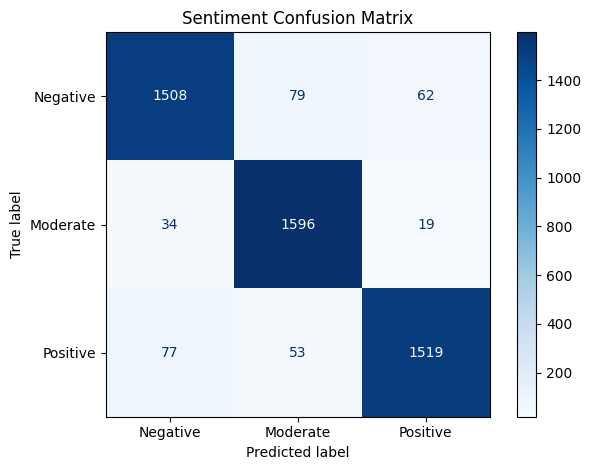

In [ ]:
# =====================================================
# 10 — Evaluation (Trainer-safe)
# =====================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

pred = trainer.predict(test_dataset)

y_true = pred.label_ids
y_prob = pred.predictions
y_pred = np.argmax(y_prob, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(
    y_true, y_pred,
    target_names=["Negative", "Moderate", "Positive"]
))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(
    cm,
    display_labels=["Negative", "Moderate", "Positive"]
).plot(cmap="Blues", values_format="d")

plt.title("Sentiment Confusion Matrix")
plt.tight_layout()
plt.show()


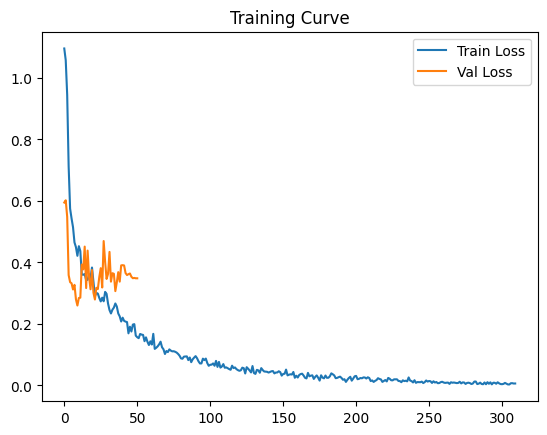

In [ ]:
# 11 - Training Curve
log_history = trainer.state.log_history
train_loss = [e["loss"] for e in log_history if "loss" in e]
eval_loss  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()

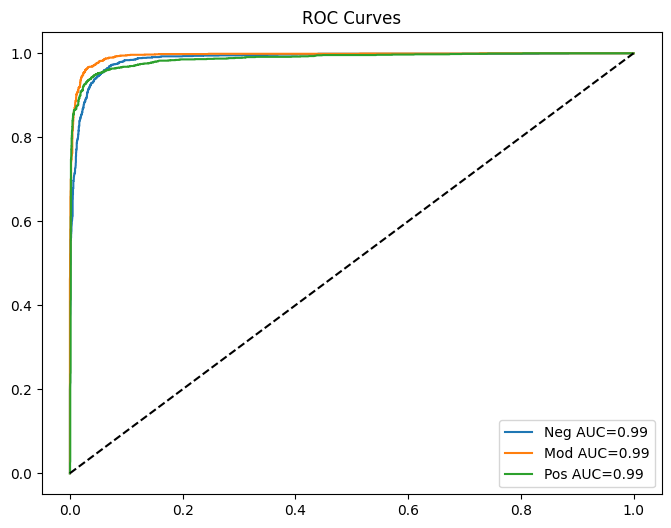

In [ ]:
# 12 - ROC Curves
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_prob = np.array(y_prob)

plt.figure(figsize=(8,6))
for i, label in enumerate(["Neg","Mod","Pos"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"k--")
plt.legend()
plt.title("ROC Curves")
plt.show()


### Continue

In [3]:
# 13 - Stage-2 Hierarchical Emotion Models (one model per sentiment group)
import os
import json
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from torch.utils.data import Dataset
from transformers import (
    AutoFeatureExtractor,
    AutoModel,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from transformers.modeling_outputs import SequenceClassifierOutput

# -------------------------------------------------------------------
# Safety fallbacks (so this cell can run standalone)
# -------------------------------------------------------------------
if "apply_cmvn" not in globals():
    def apply_cmvn(y):
        mean = np.mean(y)
        std = np.std(y) + 1e-8
        return (y - mean) / std

if "augment_audio" not in globals():
    def augment_audio(y, sr=16000):
        return y

# -------------------------------------------------------------------
# Use the same dataframe prepared earlier in the notebook
# -------------------------------------------------------------------
if "df" not in globals():
    df = pd.read_csv("DataFrame/processed_df.csv")

df = df.copy()
df["path"] = df["path"].str.replace("\\", "/", regex=False)

# Keep only emotions used in your mapping
emotion_to_sentiment_name = {
    "angry": "negative",
    "fearful": "negative",
    "disgust": "negative",
    "sad": "negative",
    "neutral": "moderate",
    "calm": "moderate",
    "happy": "positive",
    "surprised": "positive"
}

df = df[df["emotion_lb"].isin(emotion_to_sentiment_name.keys())].copy()
df["sentiment_group"] = df["emotion_lb"].map(emotion_to_sentiment_name)

print("Samples per sentiment group:")
print(df["sentiment_group"].value_counts())

# -------------------------------------------------------------------
# Generic dataset that allows different label columns
# -------------------------------------------------------------------
class SERDatasetByLabel(Dataset):
    def __init__(self, frame, extractor, label_col, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.extractor = extractor
        self.label_col = label_col
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = librosa.load(row["path"], sr=16000)

        if self.augment and random.random() < 0.6:
            y = augment_audio(y)

        y = apply_cmvn(y)
        inputs = self.extractor(
            y,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values": inputs["input_values"][0],
            "labels": torch.tensor(int(row[self.label_col]), dtype=torch.long)
        }


class Wav2Vec2EmotionHead(nn.Module):
    def __init__(self, backbone_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        hidden = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, num_labels)
        )

    def forward(self, input_values=None, attention_mask=None, labels=None):
        outputs = self.backbone(input_values=input_values, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": float((preds == labels).mean())}


# -------------------------------------------------------------------
# Train one model per sentiment group
# -------------------------------------------------------------------
BACKBONE = "facebook/wav2vec2-base"
BASE_OUT_DIR = "Models/hierarchical_sentiment_to_emotion"
os.makedirs(BASE_OUT_DIR, exist_ok=True)

extractor_h = AutoFeatureExtractor.from_pretrained(BACKBONE)
data_collator = DataCollatorWithPadding(tokenizer=extractor_h, padding=True)

all_group_results = {}

for group_name in ["negative", "moderate", "positive"]:
    group_df = df[df["sentiment_group"] == group_name].copy()

    # Build group-specific emotion labels
    emotions = sorted(group_df["emotion_lb"].unique().tolist())
    emo2id = {emo: i for i, emo in enumerate(emotions)}
    id2emo = {i: emo for emo, i in emo2id.items()}
    group_df["emotion_id"] = group_df["emotion_lb"].map(emo2id)

    print(f"\n===== Group: {group_name.upper()} =====")
    print("Emotion classes:", emotions)
    print(group_df["emotion_lb"].value_counts())

    # Skip too-small groups safely
    if len(group_df) < len(emotions) * 2:
        print("Skipped: not enough samples for stratified split.")
        continue

    train_df_g, test_df_g = train_test_split(
        group_df,
        test_size=0.2,
        stratify=group_df["emotion_id"],
        random_state=42
    )

    train_ds_g = SERDatasetByLabel(train_df_g, extractor_h, label_col="emotion_id", augment=True)
    test_ds_g = SERDatasetByLabel(test_df_g, extractor_h, label_col="emotion_id", augment=False)

    model_g = Wav2Vec2EmotionHead(BACKBONE, num_labels=len(emotions))

    # Optional partial unfreeze (last 4 transformer layers)
    for name, param in model_g.backbone.named_parameters():
        if any(f"encoder.layers.{i}" in name for i in [8, 9, 10, 11]):
            param.requires_grad = True
        else:
            param.requires_grad = False

    out_dir_g = os.path.join(BASE_OUT_DIR, group_name)
    os.makedirs(out_dir_g, exist_ok=True)

    args_g = TrainingArguments(
        output_dir=out_dir_g,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=4,
        learning_rate=3e-5,
        num_train_epochs=12,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        logging_steps=25,
        report_to="none"
    )

    trainer_g = Trainer(
        model=model_g,
        args=args_g,
        train_dataset=train_ds_g,
        eval_dataset=test_ds_g,
        tokenizer=extractor_h,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer_g.train()

    # Evaluate and save artifacts
    pred_g = trainer_g.predict(test_ds_g)
    y_true_g = pred_g.label_ids
    y_prob_g = pred_g.predictions
    y_pred_g = np.argmax(y_prob_g, axis=1)

    acc_g = accuracy_score(y_true_g, y_pred_g)
    print(f"{group_name} accuracy: {acc_g:.4f}")

    report_txt = classification_report(
        y_true_g,
        y_pred_g,
        target_names=[id2emo[i] for i in range(len(id2emo))],
        digits=3
    )
    print(report_txt)

    with open(os.path.join(out_dir_g, "label_map.json"), "w") as f:
        json.dump({"emotion2id": emo2id, "id2emotion": id2emo}, f, indent=2)

    with open(os.path.join(out_dir_g, "classification_report.txt"), "w") as f:
        f.write(report_txt)

    cm = confusion_matrix(y_true_g, y_pred_g)
    disp = ConfusionMatrixDisplay(cm, display_labels=[id2emo[i] for i in range(len(id2emo))])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {group_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir_g, "confusion_matrix.png"), dpi=200)
    plt.close()

    trainer_g.save_model(os.path.join(out_dir_g, "best_model"))
    extractor_h.save_pretrained(os.path.join(out_dir_g, "best_model"))

    all_group_results[group_name] = {
        "accuracy": float(acc_g),
        "n_samples": int(len(group_df)),
        "classes": emotions
    }

with open(os.path.join(BASE_OUT_DIR, "summary.json"), "w") as f:
    json.dump(all_group_results, f, indent=2)

print("\nSaved hierarchical models and reports to:", BASE_OUT_DIR)
print(json.dumps(all_group_results, indent=2))

Samples per sentiment group:
sentiment_group
negative    8244
positive    2759
moderate    2171
Name: count, dtype: int64


d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(



===== Group: NEGATIVE =====
Emotion classes: ['angry', 'disgust', 'fearful', 'sad']
emotion_lb
sad        2107
angry      2107
fearful    2107
disgust    1923
Name: count, dtype: int64


d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
C:\Users\helen\AppData\Local\Temp\ipykernel_10252\1481588101.py:199: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_g = Trainer(
d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [1]:
# 14 - Inference: 2-step prediction (sentiment -> subgroup emotion)
import os
import json
import torch
import librosa
import numpy as np
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

# Safety fallback (so this cell can run standalone)
if "apply_cmvn" not in globals():
    def apply_cmvn(y):
        mean = np.mean(y)
        std = np.std(y) + 1e-8
        return (y - mean) / std

SENTIMENT_MODEL_DIR = "Models/wav2vec2_sentiment_v2/best_model"
HIER_MODEL_ROOT = "Models/hierarchical_sentiment_to_emotion"
BACKBONE = "facebook/wav2vec2-base"

SENTIMENT_ID2NAME = {0: "negative", 1: "moderate", 2: "positive"}


class Wav2Vec2SentimentForInference(torch.nn.Module):
    def __init__(self, base_model, n_sentiment=3):
        super().__init__()
        self.base = base_model
        hidden = base_model.config.hidden_size
        self.sent_head = torch.nn.Sequential(
            torch.nn.Linear(hidden, hidden // 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(hidden // 2, n_sentiment)
        )

    def forward(self, input_values=None, attention_mask=None):
        outputs = self.base.wav2vec2(input_values=input_values, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state.mean(dim=1)
        logits = self.sent_head(pooled)
        return logits


def _load_sentiment_model(device):
    extractor_local = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

    base = AutoModelForAudioClassification.from_pretrained(
        "facebook/wav2vec2-base",
        num_labels=3,
        problem_type="single_label_classification"
    )
    model_local = Wav2Vec2SentimentForInference(base, n_sentiment=3)

    state_path = os.path.join(SENTIMENT_MODEL_DIR, "pytorch_model.bin")
    if not os.path.exists(state_path):
        raise FileNotFoundError(f"Sentiment model state_dict not found: {state_path}")

    state = torch.load(state_path, map_location=device)
    model_local.load_state_dict(state, strict=True)
    model_local.to(device)
    model_local.eval()

    return model_local, extractor_local


def _load_group_model(group_name, device):
    group_dir = os.path.join(HIER_MODEL_ROOT, group_name)
    model_dir = os.path.join(group_dir, "best_model")
    label_map_path = os.path.join(group_dir, "label_map.json")

    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Group model directory not found: {model_dir}")
    if not os.path.exists(label_map_path):
        raise FileNotFoundError(f"Label map missing: {label_map_path}")

    with open(label_map_path, "r") as f:
        label_map = json.load(f)

    id2emotion = {int(k): v for k, v in label_map["id2emotion"].items()}

    extractor_local = AutoFeatureExtractor.from_pretrained(model_dir)
    model_local = AutoModelForAudioClassification.from_pretrained(model_dir)
    model_local.to(device)
    model_local.eval()

    return model_local, extractor_local, id2emotion


def _prepare_audio(path):
    y, sr = librosa.load(path, sr=16000)
    y = apply_cmvn(y)
    return y


def predict_hierarchical_emotion(audio_path):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    y = _prepare_audio(audio_path)

    # -------- Step 1: sentiment --------
    sent_model, sent_extractor = _load_sentiment_model(device)
    sent_inputs = sent_extractor(y, sampling_rate=16000, return_tensors="pt", padding=True)
    sent_inputs = {k: v.to(device) for k, v in sent_inputs.items()}

    with torch.no_grad():
        sent_logits = sent_model(**sent_inputs)
        sent_probs = torch.softmax(sent_logits, dim=-1).cpu().numpy()[0]

    sent_id = int(np.argmax(sent_probs))
    sent_name = SENTIMENT_ID2NAME[sent_id]

    # -------- Step 2: subgroup emotion --------
    emo_model, emo_extractor, id2emotion = _load_group_model(sent_name, device)
    emo_inputs = emo_extractor(y, sampling_rate=16000, return_tensors="pt", padding=True)
    emo_inputs = {k: v.to(device) for k, v in emo_inputs.items()}

    with torch.no_grad():
        emo_out = emo_model(**emo_inputs)
        emo_logits = emo_out.logits if hasattr(emo_out, "logits") else emo_out["logits"]
        emo_probs = torch.softmax(emo_logits, dim=-1).cpu().numpy()[0]

    emo_id = int(np.argmax(emo_probs))
    emo_name = id2emotion[emo_id]

    result = {
        "audio_path": audio_path,
        "sentiment_id": sent_id,
        "sentiment": sent_name,
        "sentiment_probs": {
            SENTIMENT_ID2NAME[i]: float(sent_probs[i]) for i in range(len(sent_probs))
        },
        "emotion_id": emo_id,
        "emotion": emo_name,
        "emotion_probs": {
            id2emotion[i]: float(emo_probs[i]) for i in range(len(emo_probs))
        }
    }
    return result


# Example usage:
# test_audio = "Data/Processed_Audio/Actor_01/03-01-01-01-01-01-01.wav"
# out = predict_hierarchical_emotion(test_audio)
# print(json.dumps(out, indent=2))

d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using event file: Models/wav2vec2_sentiment_v2\runs\Dec13_01-36-12_fae96473d1fb\events.out.tfevents.1765589772.fae96473d1fb.1789.0


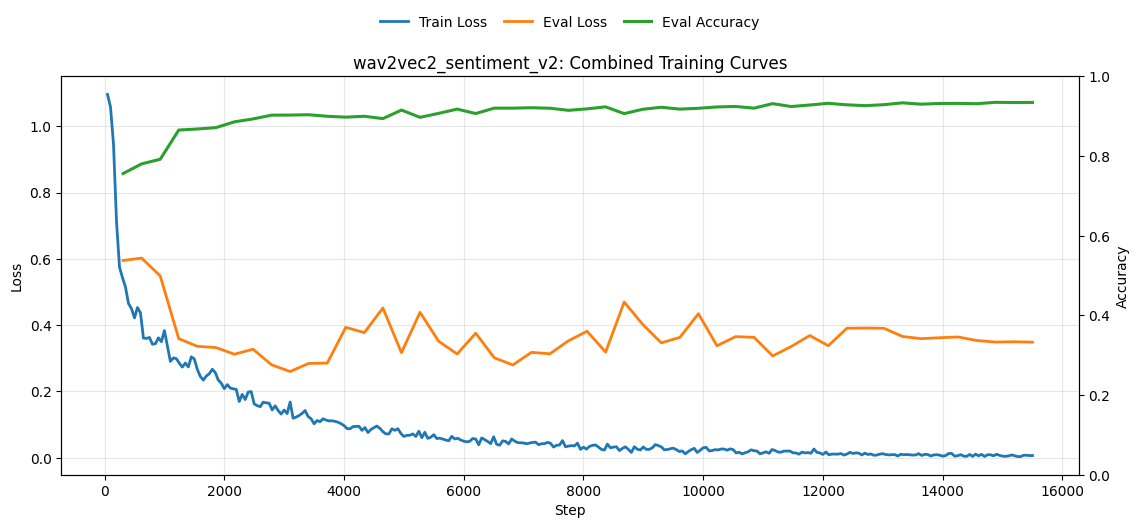

In [4]:
# 15 - Combined Accuracy & Loss for wav2vec2_sentiment_v2 (no markers)
import os
import glob
import matplotlib.pyplot as plt

MODEL_DIR = "Models/wav2vec2_sentiment_v2"
RUNS_DIR = os.path.join(MODEL_DIR, "runs")


def _extract_scalar_series(event_acc, candidate_tags):
    """Return first available scalar series among candidate tags."""
    for tag in candidate_tags:
        if tag in event_acc.Tags().get("scalars", []):
            events = event_acc.Scalars(tag)
            x = [e.step for e in events]
            y = [e.value for e in events]
            return tag, x, y
    return None, [], []


# Read TensorBoard logs so plotting still works after kernel restart.
event_files = glob.glob(os.path.join(RUNS_DIR, "**", "events.out.tfevents.*"), recursive=True)
if not event_files:
    raise FileNotFoundError(f"No TensorBoard event files found under: {RUNS_DIR}")

latest_event = max(event_files, key=os.path.getmtime)
print("Using event file:", latest_event)

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except Exception as e:
    raise ImportError(
        "tensorboard is required to read training curves. Install with: pip install tensorboard"
    ) from e

ea = EventAccumulator(latest_event)
ea.Reload()

train_loss_tag, train_x, train_loss = _extract_scalar_series(
    ea, ["train/loss", "loss", "train_loss"]
)
eval_loss_tag, eval_x, eval_loss = _extract_scalar_series(
    ea, ["eval/loss", "eval_loss", "validation/loss", "val/loss"]
)
eval_acc_tag, acc_x, eval_acc = _extract_scalar_series(
    ea, ["eval/accuracy", "eval_accuracy", "validation/accuracy", "val/accuracy"]
)

if not (train_loss or eval_loss or eval_acc):
    print("No expected scalar tags were found.")
    print("Available tags:", ea.Tags().get("scalars", []))
else:
    fig, ax1 = plt.subplots(figsize=(11.5, 5.2))

    # Left axis: losses
    if train_loss:
        ax1.plot(train_x, train_loss, linewidth=2.0, color="tab:blue", label="Train Loss")
    if eval_loss:
        ax1.plot(eval_x, eval_loss, linewidth=2.0, color="tab:orange", label="Eval Loss")

    ax1.set_xlabel("Step")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)

    # Right axis: accuracy
    ax2 = ax1.twinx()
    if eval_acc:
        ax2.plot(acc_x, eval_acc, linewidth=2.2, color="tab:green", label="Eval Accuracy")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0.0, 1.0)

    # Compact, non-overlapping legend above the plot.
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    all_lines = lines_1 + lines_2
    all_labels = labels_1 + labels_2
    if all_lines:
        fig.legend(
            all_lines,
            all_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=min(3, len(all_labels)),
            frameon=False,
            columnspacing=1.2,
            handlelength=2.0
        )

    plt.title("wav2vec2_sentiment_v2: Combined Training Curves")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
